In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


os.chdir('../..')
sys.path.append('.')
import configs
from models import resnet18
from utils.dataset import load_cv_dataset
from utils.nn import set_seed
from utils.nn.io import load_embedding

device = torch.device('cuda:0')
set_seed(0)

##### Define Basic Functions
* `finetune()`: modify and finetune the last layer on the target dataset while freezing the other layers of the given embedded model.
* `plot()`:

In [2]:
def finetune(embed, model, trainloader, testloader, epoch, lr, gamma):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    schedule  = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma)

    train_loss, train_acc = list(), list()
    test_loss, test_acc   = list(), list()

    for _ in tqdm(range(epoch)):
        # train.
        batch_loss, batch_acc = 0, 0
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                e = embed(x)
            pred = model(e)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            batch_loss += loss.detach().cpu().item()
            batch_acc  += torch.argmax(pred, dim=1).eq(y).sum().item() / y.size(0)
        schedule.step()
        train_loss.append(batch_loss / len(trainloader))
        train_acc.append(batch_acc / len(trainloader) * 100)
        # test.
        batch_loss, batch_acc = 0, 0
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                e = embed(x)
                pred = model(e)
                loss = criterion(pred, y)
                batch_loss += loss.detach().cpu().item()
                batch_acc  += torch.argmax(pred, dim=1).eq(y).sum().item() / y.size(0)
        test_loss.append(batch_loss / len(testloader))
        test_acc.append(batch_acc / len(testloader) * 100)
    return train_loss, train_acc, test_loss, test_acc

In [3]:
def plot(train_loss, train_acc, test_loss, test_acc):
    x = list(range(len(train_loss)))
    fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=100)
    ax[0].grid(linestyle='--', alpha=0.5)
    ax[0].plot(x, train_loss, label='Train Loss')
    ax[0].plot(x, test_loss, label='Test Loss')
    ax[0].set_xlim([0, x[-1]-1])
    ax[0].legend(loc='upper right')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Cross-Entropy Loss')
    ax[1].grid(linestyle='--', alpha=0.5)
    ax[1].plot(x, train_acc, label='Train Acc')
    ax[1].plot(x, test_acc, label='Test Acc')
    ax[1].set_xlim([0, x[-1]-1])
    ax[1].legend(loc='upper left')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    fig.tight_layout()
    fig.show()

#### Load CIFAR10/CIFAR100 training and test set with proper transforms.

In [4]:
bs = 256
cifar10_n_classes, cifar100_n_classes = 10, 100

cifar10_trainset    = load_cv_dataset('cifar10', train=True, augment=False)
cifar10_testset     = load_cv_dataset('cifar10', train=False, augment=False)
cifar10_trainloader = DataLoader(cifar10_trainset, batch_size=bs, shuffle=True, num_workers=0)
cifar10_testloader  = DataLoader(cifar10_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CIFAR-10 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar10_trainset.transform.transforms]))
print('CIFAR-10 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar10_testset.transform.transforms]))

cifar100_trainset    = load_cv_dataset('cifar100', train=True, augment=False)
cifar100_testset     = load_cv_dataset('cifar100', train=False, augment=False)
cifar100_trainloader = DataLoader(cifar100_trainset, batch_size=bs, shuffle=True, num_workers=0)
cifar100_testloader  = DataLoader(cifar100_testset, batch_size=bs, shuffle=False, num_workers=0)
print('CIFAR-100 training transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar100_trainset.transform.transforms]))
print('CIFAR-100 test transform:\n' + '\n'.join([f'==> {str(t)}' for t in cifar100_testset.transform.transforms]))

CIFAR-10 training transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-10 test transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-100 training transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))
CIFAR-100 test transform:
==> ToTensor()
==> Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.201))


### Discussion 1: Embedding Quality of Protogenetic/Transferring Embedding Models
It is worth exploring the change in representation quality when transferring the pre-trained embedding model to the target domain. To reveal this, we choose models pre-trained on different datasets to generate embedded representations of the target data. Corresponding linear/nonlinear classifiers are trained respectively based on the representations generated from each embedding model for a few epochs. The representation quality is measured by the accuracy of the classifiers over the target domain. By transferring the embedding model per-trained from source domains to the target domain, I try to shed light on the transfer performance and the underlying factors (both positive and negative) that influence the results.

Specifically, I choose models pre-trained with ImageNet1k, CIFAR-10, and CIFAR-100 as embedding models and CIFAR-100 as the target domain. Compared with CIFAR-100, ImageNet1k contains more categories and samples, which makes the model trained based on it more generalized. But the feature size of ImageNet1k is relatively large, resulting in larger convolution kernels and step sizes of the corresponding neural network. It will sacrifice the ability to learn details from feature spaces with smaller sizes. On the contrary, CIFAR-10 has the same feature size and similar data latent distribution as CIFAR-100. But the classes of CIFAR-10 are quite few than CIFAR-100, meaning that the generalization ability of models trained on CIFAR-10 should be intuitively weaker than that of CIFAR-100. An additional experiment of transferring the embedding model pre-trained on CIFAR-100 to the CIFAR-10 is supplemented, in order to investigate the performence of transferring models from a general domain to a specific domain with high similarity of latent distribution. By conducting experiments mentioned above, I will reveal whether *the generalization ability* or *the similarity between the source and target domains* contribute more to the embedding quality. The results suggest this assumption is true.

In addition, in order to explore whether the problem of linear inseparability will occur when transferring the embedding model to target domains, I add a set of experiments that use a two-layer MLP instead of linear to improve the nonlinear classification ability of the classifiers. The little improvement in the performance of using MLP instead of linear indicates the embedding generated by the transferred model is usually linearly separable.

In [5]:
epoch = 50
lr    = 1e-3
gamma = 0.99

#### Exp 1.1: Finetune Linear and MLP by CIFAR-100 data based on **Protogenetic** Pre-trained Embedding.

In [6]:
embed = resnet18(**configs.resnet18_cifar100_params)
state = load_embedding('resnet18', 'cifar100', 'sl', '230429-1218')
embed.load_state_dict(state, strict=True)
embed = embed.to(device)

num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
linear   = nn.Linear(num_ftrs, cifar100_n_classes).to(device)
mlp      = nn.Sequential(nn.Linear(num_ftrs, 2 * num_ftrs), nn.ReLU(), nn.Linear(2 * num_ftrs, cifar100_n_classes)).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

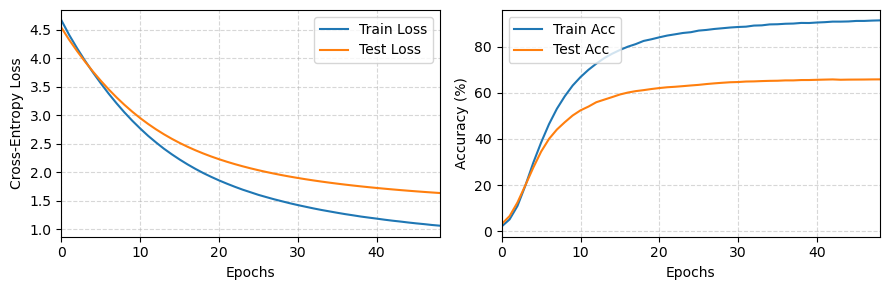

In [7]:
# result of finetuning linear based on protogenetic pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

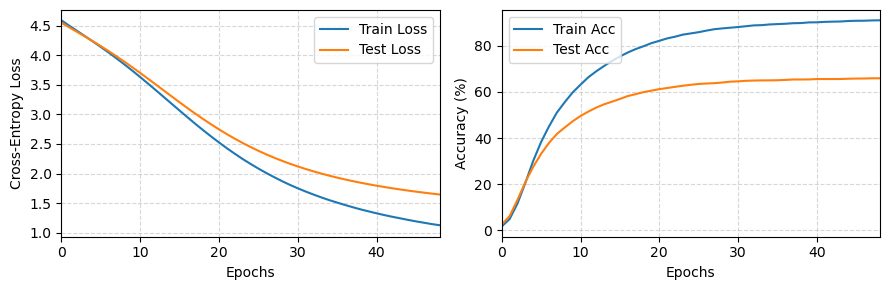

In [8]:
# result of finetuning MLP based on protogenetic pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, mlp, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

#### Exp 1.2: Finetune Linear and MLP by CIFAR-100 data based on **CIFAR-10** Pre-trained Embedding.

In [9]:
embed = resnet18(**configs.resnet18_cifar10_params)
state = load_embedding('resnet18', 'cifar10', 'sl', '230429-1218')
embed.load_state_dict(state, strict=True)
embed = embed.to(device)

num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
linear   = nn.Linear(num_ftrs, cifar100_n_classes).to(device)
mlp      = nn.Sequential(nn.Linear(num_ftrs, 2 * num_ftrs), nn.ReLU(), nn.Linear(2 * num_ftrs, cifar100_n_classes)).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

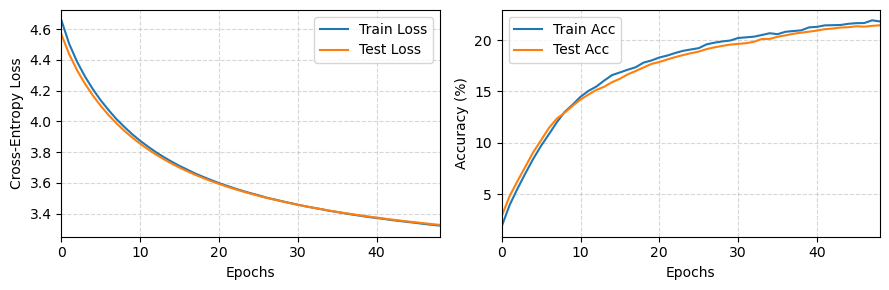

In [10]:
# result of finetuning linear based on protogenetic pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

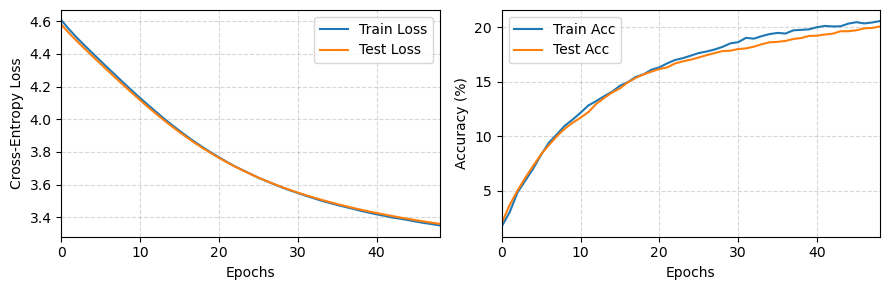

In [11]:
# result of finetuning MLP based on protogenetic pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, mlp, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

#### Exp 1.3: Finetune Linear and MLP by CIFAR-100 data based on **ImageNet1k** Pre-trained Embedding.

In [12]:
embed = resnet18(**configs.resnet18_imagenet1k_params)
state = load_embedding('resnet18', 'imagenet1k', 'sl', '666666-6666')
embed.load_state_dict(state, strict=False)
embed = embed.to(device)

num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
linear   = nn.Linear(num_ftrs, cifar100_n_classes).to(device)
mlp      = nn.Sequential(nn.Linear(num_ftrs, 2 * num_ftrs), nn.ReLU(), nn.Linear(2 * num_ftrs, cifar100_n_classes)).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

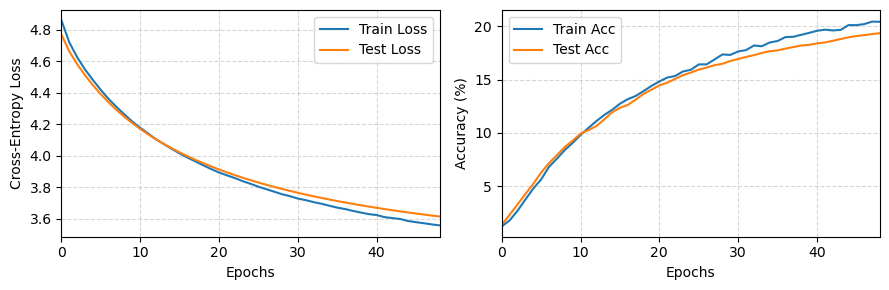

In [13]:
# result of finetuning linear based on ImageNet1k pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

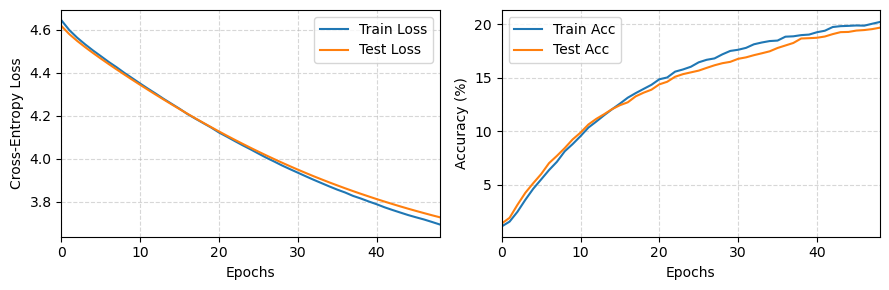

In [14]:
# result of finetuning MLP based on ImageNet1k pre-trained embedding.
train_loss, train_acc, test_loss, test_acc = finetune(embed, mlp, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

#### Exp 1.4: Finetune Linear and MLP by **CIFAR-10** data based on **CIFAR-100** Pre-trained Embedding.

In [15]:
embed = resnet18(**configs.resnet18_cifar100_params)
state = load_embedding('resnet18', 'cifar100', 'sl', '230429-1218')
embed.load_state_dict(state, strict=True)
embed = embed.to(device)

num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
linear   = nn.Linear(num_ftrs, cifar10_n_classes).to(device)
mlp      = nn.Sequential(nn.Linear(num_ftrs, 2 * num_ftrs), nn.ReLU(), nn.Linear(2 * num_ftrs, cifar10_n_classes)).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

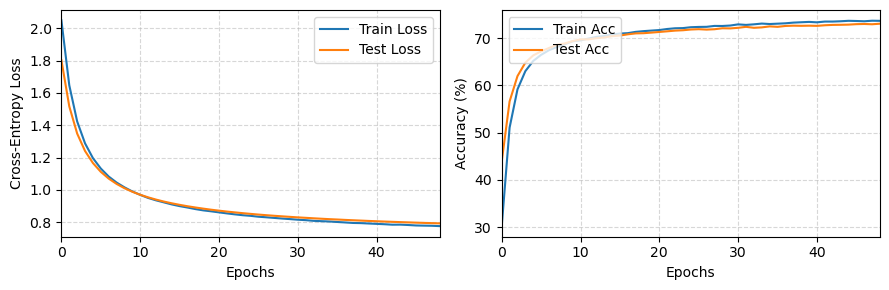

In [16]:
train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar10_trainloader, cifar10_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

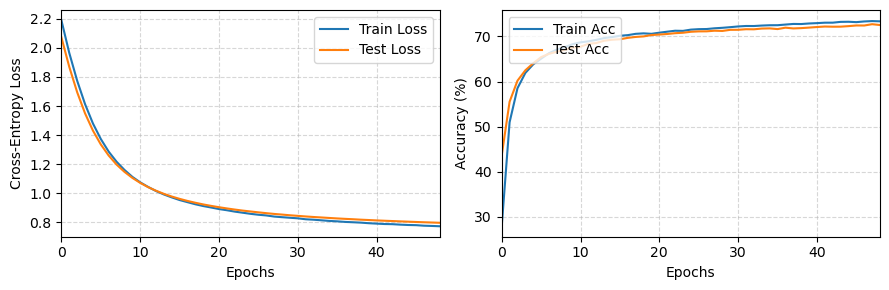

In [17]:
train_loss, train_acc, test_loss, test_acc = finetune(embed, mlp, cifar10_trainloader, cifar10_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

#### Exp 1.5: Finetune Linear and MLP by **CIFAR-10** data based on **ImageNet1k** Pre-trained Embedding.

In [18]:
embed = resnet18(**configs.resnet18_imagenet1k_params)
state = load_embedding('resnet18', 'imagenet1k', 'sl', '666666-6666')
embed.load_state_dict(state, strict=True)
embed = embed.to(device)

num_ftrs = embed.fc.in_features
embed.fc = torch.nn.Identity()
linear   = nn.Linear(num_ftrs, cifar10_n_classes).to(device)
mlp      = nn.Sequential(nn.Linear(num_ftrs, 2 * num_ftrs), nn.ReLU(), nn.Linear(2 * num_ftrs, cifar10_n_classes)).to(device)

  0%|          | 0/50 [00:00<?, ?it/s]

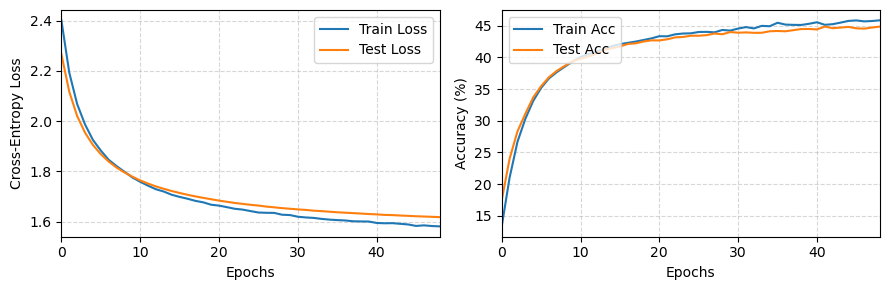

In [19]:
train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar10_trainloader, cifar10_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

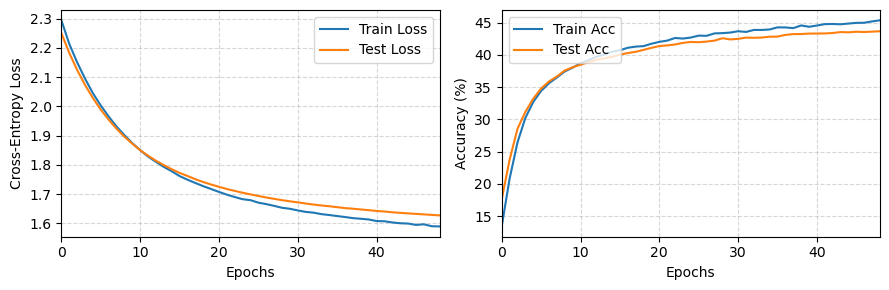

In [20]:
train_loss, train_acc, test_loss, test_acc = finetune(embed, mlp, cifar10_trainloader, cifar10_testloader, epoch=epoch, lr=lr, gamma=gamma)
plot(train_loss, train_acc, test_loss, test_acc)

### Discussion 2: Relationship between Pre-training Performance and Downstream Performance

In [21]:
epoch = 50
lr    = 1e-3
gamma = 0.9

In [22]:
ckps = [0, 10, 20, 30, 40, 50]
ckp_accs = [84.81, 90.00, 92.04, 92.70, 93.06]
train_losses, train_accs, test_losses, test_accs = list(), list(), list(), list()

for ckp in ckps:
    embed = resnet18(**configs.resnet18_cifar10_params)
    if ckp:
        state = load_embedding('resnet18', 'cifar10', 'sl', '230429-1218', epoch=ckp)
        embed.load_state_dict(state, strict=True)
    embed    = embed.to(device)
    num_ftrs = embed.fc.in_features
    embed.fc = torch.nn.Identity()
    linear   = nn.Linear(num_ftrs, cifar100_n_classes).to(device)
    train_loss, train_acc, test_loss, test_acc = finetune(embed, linear, cifar100_trainloader, cifar100_testloader, epoch=epoch, lr=lr, gamma=gamma)
    train_losses.append(train_loss[-1]), train_accs.append(train_acc[-1]), test_losses.append(test_loss[-1]), test_accs.append(test_acc[-1])

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

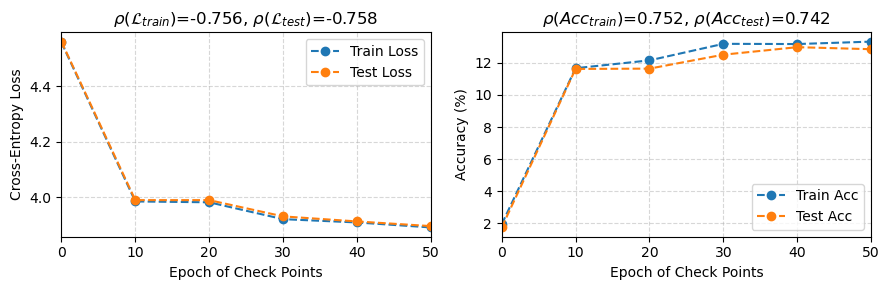

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3), dpi=100)
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].plot(ckps, train_losses, '--o', label='Train Loss')
ax[0].plot(ckps, test_losses, '--o', label='Test Loss')
ax[0].set_title(r'$\rho(\mathcal{L}_{train})$='+ str(round(np.corrcoef(ckps, train_losses)[0,1],3)) + \
                r', $\rho(\mathcal{L}_{test})$='+ str(round(np.corrcoef(ckps, test_losses)[0,1],3)))
ax[0].set_xlim([0, ckps[-1]])
ax[0].legend(loc='upper right')
ax[0].set_xlabel('Epoch of Check Points')
ax[0].set_ylabel('Cross-Entropy Loss')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].plot(ckps, train_accs, '--o', label='Train Acc')
ax[1].plot(ckps, test_accs, '--o', label='Test Acc')
ax[1].set_title(r'$\rho(Acc_{train})$='+ str(round(np.corrcoef(ckps, train_accs)[0,1],3)) + \
                r', $\rho(Acc_{test})$='+ str(round(np.corrcoef(ckps, test_accs)[0,1],3)))
ax[1].set_xlim([0, ckps[-1]])
ax[1].legend(loc='lower right')
ax[1].set_xlabel('Epoch of Check Points')
ax[1].set_ylabel('Accuracy (%)')
fig.tight_layout()
fig.show()